# Investigations of datasets from arxiv and huggingface
With the purpose of comparing trends in the two sources, at the same time period, the goal here is to find a common time period with plenty of data in both datasets.
We then want to create subsets of the datasets, with time stamps uniformly distributed.

In [236]:
import dataset_loader
from matplotlib import pyplot as plt

In [237]:
arx = dataset_loader._load_arxiv_timeline()
hf = dataset_loader._load_hf_timeline()

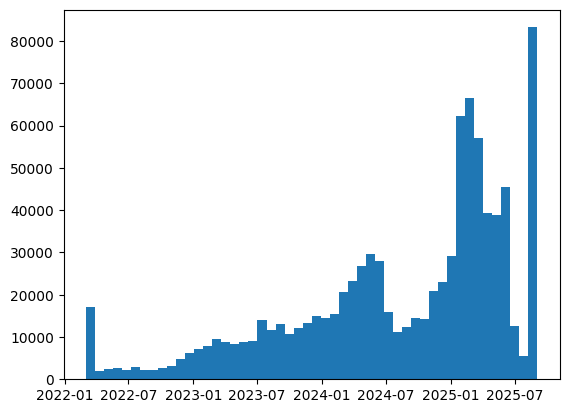

In [239]:
plt.hist(hf["createdAt"], bins=50)
plt.show()

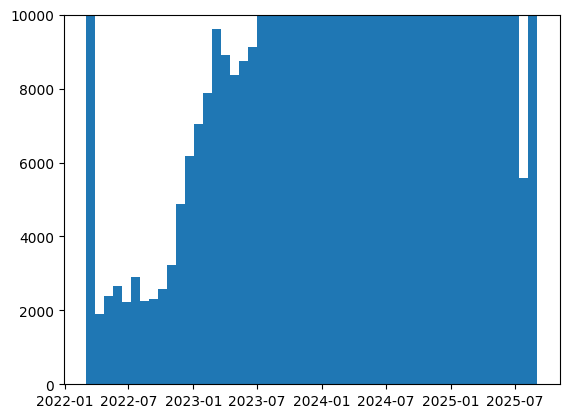

In [240]:
plt.hist(hf["createdAt"], bins=50)
plt.ylim(0, 10000)
plt.show()

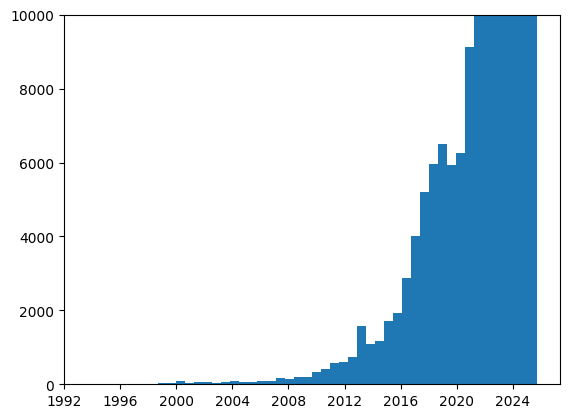

In [241]:
plt.hist(arx["submission_date"], bins=50)
plt.ylim(0, 10000)
plt.show()

In [32]:
#plt.hist(
dur = (hf_df["last_modified"]-hf_df["createdAt"])
dur.mean(), dur.max(), dur.median()

(Timedelta('13 days 10:26:45.031926318'),
 Timedelta('1278 days 10:00:28'),
 Timedelta('0 days 00:12:09'))

# binned data
we divide the data into bins based on date. We want lots of bins for high granularity, but also need plenty of data in each bin for it to be useful. Also, very fine granularity is not nescessary since the dates do not represent trend time that exactly (eg arxiv papers are developed ofer months then published).
Therefore, bins are based on month.

In [209]:
import dataset_loader

In [210]:
arx = dataset_loader._load_arxiv_timeline()
hf = dataset_loader._load_hf_timeline()

In [211]:
def group_dfs_in_months(m = 3): #m= number of months to combine in a bin (e.g. m=3 means we look at quarters)
    arx["bin"] = ((arx["submission_date"].dt.month+m-1)//m)/100 + arx["submission_date"].dt.year
    hf["bin"] = ((hf["createdAt"].dt.month+m-1)//m)/100 + hf["createdAt"].dt.year


In [212]:
def find_longest_true_sebseq(series, debug = False):
    # find longest consecutive subsequence of True

    # count position in subseq
    s2 = series.copy()
    s2 = s2.astype(int)
    count=0
    for id in series.index:
        if series.loc[id]:
            count +=1
        else:
            count = 0
        s2.loc[id] = count

    if debug:
        return s2
    series = series.iloc[:s2.argmax()+1] # remove part after the longest subseq
    series = series.iloc[-series[::-1].argmin():] # remove part before
    assert all(series)

    return series

def find_commonly_plentiful_subseries(threshold = 2000):

    arxiv_plentiful_months = arx.groupby(["bin"]).count()["title"] >= threshold
    hf_plentiful_months = hf.groupby(["bin"]).count()["modelId"] >= threshold

    both_plentify_months = arxiv_plentiful_months & hf_plentiful_months

    start = both_plentify_months[both_plentify_months==True].index.min()
    end = both_plentify_months[both_plentify_months==True].index.max()

    period = both_plentify_months.loc[start:end]

    return period



In [213]:

for m in [1,2,3,4]:
    group_dfs_in_months(m)
    print("m=", m)
    maxsums = [0]
    best_threshs = [0]
    prevl=0
    for threshold in range(1100, 10000, 100):
        period = find_commonly_plentiful_subseries(threshold)
        if len(period)==0:
            break
        series = find_longest_true_sebseq(period)
        l=len(series)
        sum_ = l*threshold
        if sum_>maxsums[-1]:
            maxsums.append(sum_)
            best_threshs.append(threshold)
            if l != prevl:
                print(prevl, maxsums[-2], best_threshs[-2])
            prevl = l
    print(prevl, maxsums[-1], best_threshs[-1])



m= 1
0 0 0
43 47300 1100
32 48000 1500
m= 2
0 0 0
22 39600 1800
21 54600 2600
m= 3
0 0 0
15 60000 4000
14 63000 4500
m= 4
0 0 0
12 21600 1800
11 61600 5600


In [214]:
# to find exact numbers
import pandas as pd
group_dfs_in_months(1)
pd.concat([arx.groupby(["bin"]).count()["title"], hf.groupby(["bin"]).count()["modelId"]], axis=1).min(axis=1)


bin
1993.08       2.0
1993.09       1.0
1993.11       2.0
1993.12       1.0
1994.01       1.0
            ...  
2025.05    4185.0
2025.06    3425.0
2025.07    1517.0
2025.08    3486.0
2025.09    1862.0
Length: 369, dtype: float64

In [215]:
for threshold in [1103, 1517]: # these are the exact numbers in the months with fewest arxiv papers.
    period = find_commonly_plentiful_subseries(threshold)
    series = find_longest_true_sebseq(period)
    l=len(series)
    sum_ = l*threshold
    print(l, sum_, threshold)

43 47429 1103
32 48544 1517


Choosing m=1 for granularity since its not that much less than m=2 and m=3. Also choosing threshold of 1103, since it covers a lot longer period than 1517 and only slightly fewer examples.

In [216]:
threshold = 1103
period = find_commonly_plentiful_subseries(threshold)
bin_range = period.index.min(), period.index.max()

In [223]:
arx = arx[arx["bin"]>=bin_range[0]][arx["bin"]<=bin_range[1]]
hf = hf[hf["bin"]>=bin_range[0]][hf["bin"]<=bin_range[1]]

In [224]:
#= arx.groupby(["bin"]).count()["title"]
hf = hf.groupby(["bin"]).sample(n=1103, random_state = 123)

In [225]:
arx = arx.groupby(["bin"]).sample(n=1103, random_state = 123)

In [218]:

#arx.groupby(["bin"]).count()["title"]
hf.groupby(["bin"]).count()["modelId"]

bin
2022.03    17232
2022.04     2203
2022.05     3183
2022.06     2785
2022.07     3538
2022.08     2659
2022.09     2853
2022.10     3484
2022.11     4431
2022.12     7556
2023.01     8461
2023.02     9039
2023.03    11532
2023.04     9893
2023.05    10508
2023.06    10618
2023.07    16151
2023.08    14481
2023.09    14543
2023.10    13975
2023.11    15233
2023.12    17492
2024.01    18912
2024.02    18947
2024.03    26303
2024.04    31117
2024.05    36326
2024.06    29591
2024.07    17227
2024.08    13668
2024.09    15979
2024.10    17889
2024.11    24682
2024.12    27653
2025.01    62953
2025.02    70689
2025.03    70535
2025.04    46488
2025.05    46949
2025.06    43686
2025.07     1517
2025.08    82648
2025.09     5113
Name: modelId, dtype: int64

In [219]:
hf

,modelId,createdAt,last_modified,bin
0,dp1812/celestial-mistral-7b-comprehensive,2025-08-28 19:37:18,2025-09-02 03:09:59,2025.08
1,mooperyou/blockassist-bc-beaked_frisky_ox_1756...,2025-09-02 03:09:12,2025-09-02 03:09:47,2025.09
2,rafitesnet00/blockassist-bc-scruffy_mighty_was...,2025-09-02 02:52:45,2025-09-02 02:56:48,2025.09
3,omerbektass/blockassist-bc-insectivorous_bold_...,2025-09-02 02:30:52,2025-09-02 02:30:55,2025.09
4,pictgensupport/Dragon3_733,2025-09-02 02:29:53,2025-09-02 02:29:56,2025.09
...,...,...,...,...
910717,sgonzalezygil/sd-finetuning-dreambooth-v5-500,2025-06-17 21:58:31,2025-06-17 22:01:12,2025.06
910718,Davidozito/fewshot-250-samples,2025-06-17 13:01:41,2025-06-17 14:16:59,2025.06
910719,milpu02/kutibuemix-xl,2025-06-17 11:07:01,2025-06-17 11:07:13,2025.06
910720,ReallyFloppyPenguin/Jan-nano-GGUF,2025-06-16 15:59:22,2025-06-16 16:08:29,2025.06


In [222]:
hf.groupby(["bin"]).sample(n=1103, random_state = 123)

,modelId,createdAt,last_modified,bin
883573,allenai/unifiedqa-v2-t5-base-1363200,2022-03-02 23:29:05,2023-01-24 16:28:24,2022.03
619409,Helsinki-NLP/opus-mt-it-bg,2022-03-02 23:29:04,2023-08-16 11:58:46,2022.03
158464,wietsedv/wav2vec2-large-xlsr-53-dutch,2022-03-02 23:29:05,2023-09-11 08:54:57,2022.03
905004,huggingtweets/shishibane,2022-03-02 23:29:05,2021-06-23 18:24:55,2022.03
450388,hfl/chinese-legal-electra-small-discriminator,2022-03-02 23:29:05,2021-01-22 05:19:55,2022.03
...,...,...,...,...
907016,kunalsbhat/contractiq-gnx-20b-multidataset,2025-09-02 02:51:38,2025-09-02 02:51:40,2025.09
247,TheHuy/gpt-neo-1.3B-vietnamese,2025-09-01 15:32:36,2025-09-01 15:37:22,2025.09
907659,Muapi/zavy-s-cyberpunk-city-flux,2025-09-01 21:42:41,2025-09-01 21:43:20,2025.09
450602,acidjp/blockassist-bc-pesty_extinct_prawn_1756...,2025-09-02 05:46:46,2025-09-02 05:46:50,2025.09


In [221]:
hf.groupby(["bin"]).sample(n=1, random_state = 123)

,modelId,createdAt,last_modified,bin
883573,allenai/unifiedqa-v2-t5-base-1363200,2022-03-02 23:29:05,2023-01-24 16:28:24,2022.03
900471,nntadotzip/bert-base-cased-IUChatbot-ontologyD...,2022-04-12 07:53:07,2022-04-12 08:14:00,2022.04
443610,TweebankNLP/bertweet-tb2_ewt-pos-tagging,2022-05-03 16:15:03,2022-05-05 00:23:51,2022.05
441421,nawta/wav2vec2-base-timit-demo-colab,2022-06-27 16:04:16,2022-06-28 12:47:04,2022.06
895793,chiendvhust/distilbert-base-uncased-finetuned-...,2022-07-06 09:44:38,2022-08-03 05:02:50,2022.07
439134,DOOGLAK/Tagged_Uni_100v0_NER_Model_3Epochs_AUG...,2022-08-11 17:53:19,2022-08-11 17:58:39,2022.08
893611,sd-concepts-library/guttestreker,2022-09-24 04:19:26,2022-09-24 04:19:49,2022.09
891812,reza-aditya/distilroberta-base-sentence-transf...,2022-10-25 00:36:01,2022-10-25 03:01:56,2022.10
891023,jjjj-j/distilbert-base-uncasedreference-finetu...,2022-11-11 14:06:04,2022-11-11 14:42:32,2022.11
886941,salehi/salehi_unit1,2022-12-26 10:20:25,2022-12-26 10:20:46,2022.12


In [235]:
all(hf.groupby(["bin"]).count()["modelId"]==1103)

True

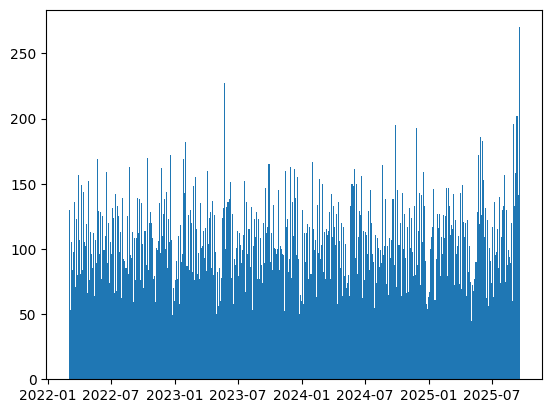

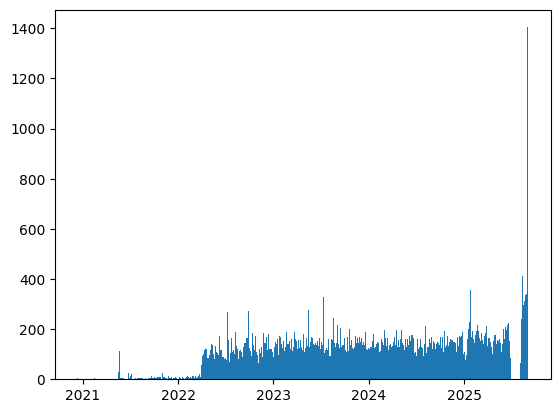

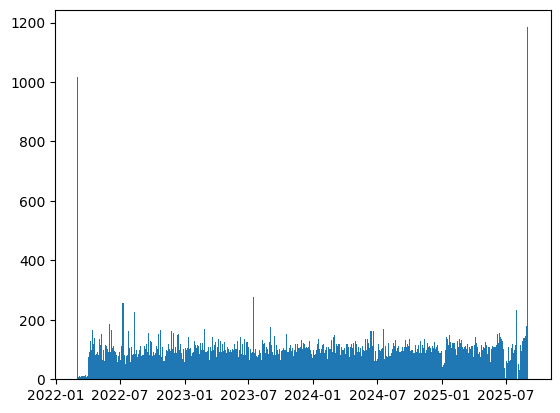

In [230]:
import matplotlib.pyplot as plt
plt.hist(arx["submission_date"], bins=440)
plt.show()
plt.hist(hf["last_modified"], bins=440)
plt.show()
plt.hist(hf["createdAt"], bins=440)
plt.show()